# Dynamic Factor Model for the Joint Evolution of Outcomes

This notebook follows the research question in your screenshot: do economic outcomes move first and psychological outcomes follow, or do they respond contemporaneously after cash transfers?

## Important identification note

The cleaned file `UCT_FINAL_CLEAN.dta` is a **wide baseline/endline dataset**, not a many-wave household panel. That means a conventional household-level VAR with repeated monthly observations is not available from this public cleaned file.

To stay close to your goal while respecting the data structure, this notebook estimates an **event-time Dynamic Factor Model (DFM)**:

- baseline outcomes are treated as the pre-transfer state
- treated endline outcomes are grouped by months since the last transfer using `Dlastend`
- a single latent factor summarizes the common evolution of assets, consumption, food security, enterprise revenue, and psychological well-being
- the transfer variable is the assigned transfer amount proxy: about `404` PPP USD for small transfers and `1525` PPP USD for large transfers

This is the cleanest way to study joint evolution with the variables currently available.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.sandwich_covariance import cov_cluster
from statsmodels.sandbox.regression.gmm import IV2SLS
from statsmodels.tsa.statespace.dynamic_factor import DynamicFactor

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "Correction" / "Data").exists():
    PROJECT_ROOT = PROJECT_ROOT / "advanced-econometrics-project"

DATA_PATH = PROJECT_ROOT / "Correction" / "Data" / "UCT_FINAL_CLEAN.dta"
VARLIST_PATH = PROJECT_ROOT/ "varlist.xlsx"

OUTCOME_VARS = [
    "asset_total_ppp",
    "cons_nondurable_ppp",
    "ent_total_rev_ppp",
    "fs_hhfoodindexnew",
    "psy_index_z",
]

TRANSFER_SMALL_PPP = 404.0
TRANSFER_LARGE_PPP = 1525.0

df = pd.read_stata(DATA_PATH)
varlist = pd.read_excel(VARLIST_PATH)
var_labels = dict(zip(varlist["varname"], varlist["varlabel"]))

label_table = pd.DataFrame({
    "variable": OUTCOME_VARS,
    "label": [var_labels.get(v, v) for v in OUTCOME_VARS],
})

print(f"Data shape: {df.shape}")
label_table

Data shape: (2880, 981)


,variable,label
0,asset_total_ppp,asset_total_ppp
1,cons_nondurable_ppp,cons_nondurable_ppp
2,ent_total_rev_ppp,ent_total_rev_ppp
3,fs_hhfoodindexnew,fs_hhfoodindexnew
4,psy_index_z,psy_index_z


In [5]:
# Household-level sample used for non-psych outcomes in the original project.
# Male respondent rows are removed to avoid duplicating household observations.
df_hh = df[(df["endlinedate"].notna()) & (df["purecontrol"] != 1) & (df["maleres"] != 1)].copy()

# Individual-level sample is needed because psych outcomes appear at the respondent level.
df_indiv = df[(df["endlinedate"].notna()) & (df["purecontrol"] != 1)].copy()

# Collapse psych outcomes to the household level so all outcomes line up on surveyid.
psych_household = (
    df_indiv.groupby("surveyid")[["psy_index_z0", "psy_index_z1"]]
    .mean()
    .reset_index()
)

base_cols = [
    "surveyid",
    "village",
    "treat",
    "spillover",
    "purecontrol",
    "treatXlarge",
    "treatXsmall",
    "treatXmonthly",
    "treatXlump",
    "treatXmonthlyXsmall",
    "treatXlumpXsmall",
    "Dlastend",
    "Dfirstend",
    "Dmeanend",
    "Dmedend",
    "endline_timing",
]

for outcome in OUTCOME_VARS:
    if outcome != "psy_index_z":
        base_cols.extend([f"{outcome}0", f"{outcome}1"])

hh_panel = (
    df_hh[base_cols]
    .drop_duplicates(subset="surveyid")
    .merge(psych_household, on="surveyid", how="left")
)

hh_panel["assigned_transfer_ppp"] = np.select(
    [hh_panel["treat"] != 1, hh_panel["treatXlarge"] == 1, hh_panel["treat"] == 1],
    [0.0, TRANSFER_LARGE_PPP, TRANSFER_SMALL_PPP],
    default=np.nan,
)

hh_panel["transfer_arm"] = np.select(
    [
        hh_panel["treat"] != 1,
        hh_panel["treatXlarge"] == 1,
        hh_panel["treatXmonthly"] == 1,
        hh_panel["treatXlump"] == 1,
    ],
    ["control_or_spillover", "large", "monthly_small", "lump_small"],
    default="treated_other",
)

records = []
for period in [0, 1]:
    tmp = hh_panel[[
        "surveyid", "village", "treat", "spillover", "transfer_arm",
        "assigned_transfer_ppp", "Dlastend", "Dfirstend", "Dmeanend", "Dmedend"
    ]].copy()
    tmp["period"] = period
    tmp["period_label"] = "baseline" if period == 0 else "endline"

    if period == 0:
        tmp["event_month"] = 0
        tmp["months_since_last_transfer"] = np.nan
        tmp["observed_transfer_ppp"] = 0.0
    else:
        tmp["months_since_last_transfer"] = tmp["Dlastend"]
        tmp["event_month"] = tmp["Dlastend"].round().clip(lower=1, upper=14)
        tmp["observed_transfer_ppp"] = tmp["assigned_transfer_ppp"]

    for outcome in OUTCOME_VARS:
        tmp[outcome] = hh_panel[f"{outcome}{period}"]

    records.append(tmp)

long_df = pd.concat(records, ignore_index=True)
long_df["event_month"] = long_df["event_month"].astype("Int64")

# Standardize using the baseline distribution so movement is interpretable across domains.
for outcome in OUTCOME_VARS:
    baseline_mean = long_df.loc[long_df["period"] == 0, outcome].mean()
    baseline_std = long_df.loc[long_df["period"] == 0, outcome].std()
    long_df[f"{outcome}_zscore"] = (long_df[outcome] - baseline_mean) / baseline_std

display(hh_panel[["surveyid", "transfer_arm", "assigned_transfer_ppp", "Dlastend"]].head())
print(f"Household-level panel rows: {len(hh_panel):,}")
print(f"Long event-time rows: {len(long_df):,}")

/var/folders/nh/x8n6mljj5g5fjmc329q4bp6h0000gn/T/ipykernel_5250/2159306883.py:84: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  long_df = pd.concat(records, ignore_index=True)


,surveyid,transfer_arm,assigned_transfer_ppp,Dlastend
0,106540326.0,control_or_spillover,0.0,NaN
1,106769148.0,lump_small,404.0,5.489810
2,106799419.0,control_or_spillover,0.0,NaN
3,106854772.0,control_or_spillover,0.0,NaN
4,106979214.0,monthly_small,404.0,5.095332


Household-level panel rows: 940
Long event-time rows: 1,880


## Build the event-time series for the Dynamic Factor Model

The DFM is estimated on treated households only. Baseline is event month `0`, and endline observations are grouped by `Dlastend`, the number of months between the last transfer and the endline survey. This mirrors the paper's timing logic.

Because the cleaned file does not contain the full payment ledger, the notebook uses **assigned transfer amount** plus **survey timing** rather than an exact installment-by-installment cumulative transfer path.

In [6]:
treated_long = long_df[long_df["treat"] == 1].copy()

z_cols = [f"{outcome}_zscore" for outcome in OUTCOME_VARS]

event_panel = (
    treated_long.groupby("event_month")[z_cols]
    .mean()
    .sort_index()
)

event_counts = treated_long.groupby("event_month").size().rename("n_households")
event_transfer = (
    treated_long.groupby("event_month")[["observed_transfer_ppp"]]
    .mean()
    .reindex(event_panel.index)
)

# Fill interior gaps caused by sparse month bins.
event_panel = event_panel.interpolate(limit_direction="both")
event_transfer = event_transfer.interpolate(limit_direction="both").fillna(0.0)

display(pd.concat([event_counts, event_transfer], axis=1))

if len(event_panel) < 6:
    raise ValueError("Too few event-time bins to estimate a useful dynamic factor model.")

dfm = DynamicFactor(
    endog=event_panel,
    exog=event_transfer,
    k_factors=1,
    factor_order=1,
    error_order=0,
    error_cov_type="diagonal",
)

dfm_res = dfm.fit(disp=False, maxiter=1000)
common_factor = pd.Series(
    np.asarray(dfm_res.factors.smoothed).squeeze(),
    index=event_panel.index,
    name="latent_welfare_factor",
)

# Simple loading proxy: correlation between each standardized outcome path and the smoothed factor.
loading_proxy = event_panel.apply(lambda s: s.corr(common_factor)).sort_values(ascending=False)

print(dfm_res.summary())
loading_proxy.to_frame("corr_with_common_factor")

,n_households,observed_transfer_ppp
event_month,,
0,471,0.000000
1,76,964.500000
2,61,1139.081967
3,83,849.698795
4,65,662.692308
5,41,458.682927
6,25,404.000000
7,15,404.000000
8,20,404.000000


                                                                                     Statespace Model Results                                                                                     
Dep. Variable:     ['asset_total_ppp_zscore', 'cons_nondurable_ppp_zscore', 'ent_total_rev_ppp_zscore', 'fs_hhfoodindexnew_zscore', 'psy_index_z_zscore']   No. Observations:                   15
Model:                                                                                                                  DynamicFactor(factors=1, order=1)   Log Likelihood                   0.562
                                                                                                                                           + 1 regressors   AIC                             30.876
Date:                                                                                                                                    Sat, 28 Mar 2026   BIC                             42.205
Time:                    

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,corr_with_common_factor
psy_index_z_zscore,0.815703
asset_total_ppp_zscore,0.416354
ent_total_rev_ppp_zscore,0.061367
fs_hhfoodindexnew_zscore,-0.639980
cons_nondurable_ppp_zscore,-0.896040


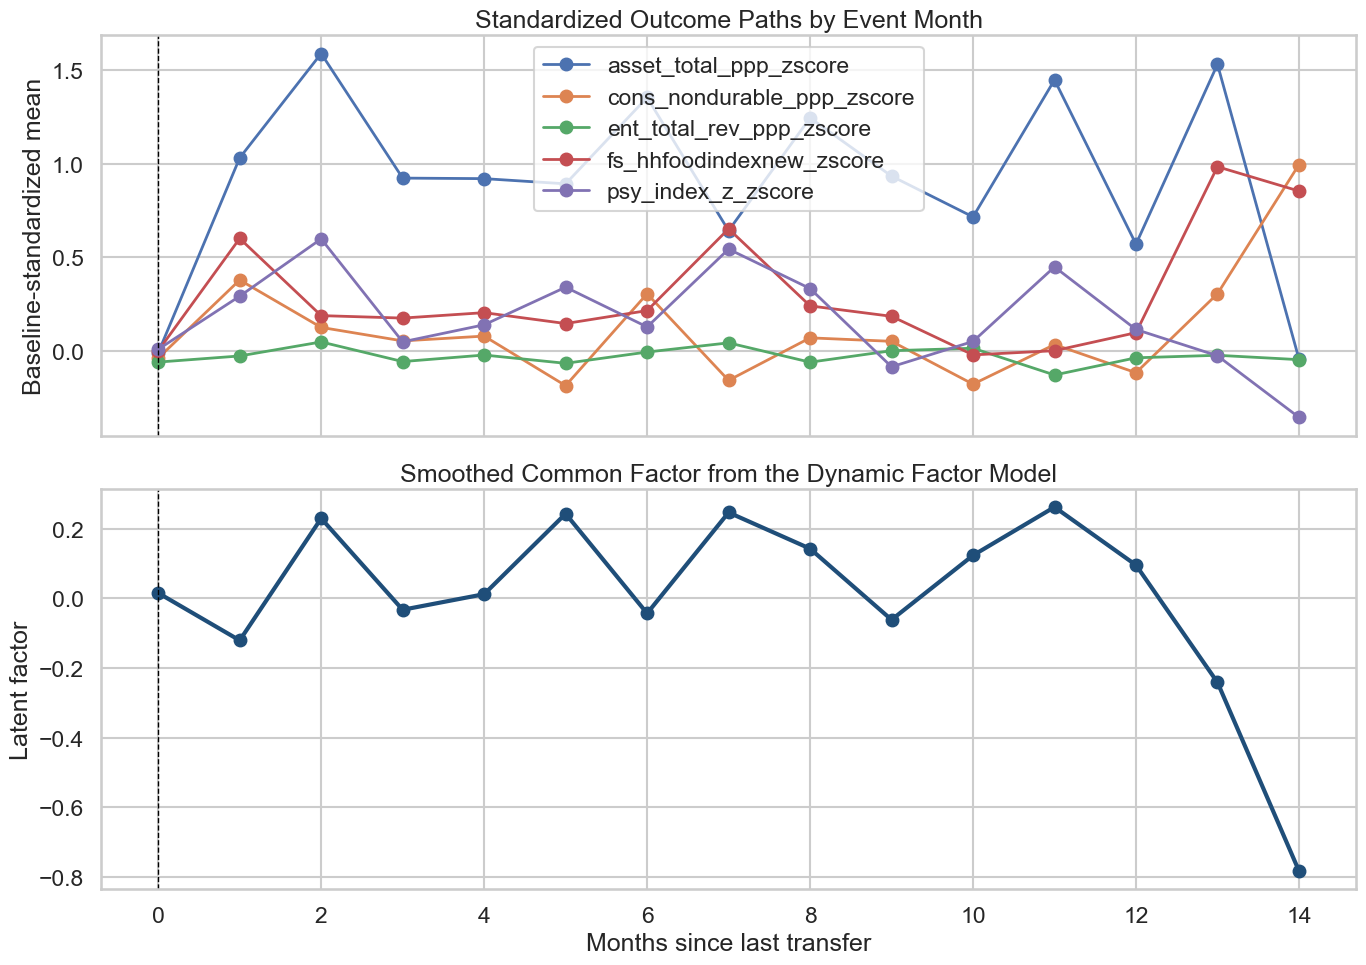

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

event_panel.rename(columns=lambda c: c.replace("_zscore", "")).plot(
    marker="o",
    linewidth=2,
    ax=axes[0],
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Standardized Outcome Paths by Event Month")
axes[0].set_ylabel("Baseline-standardized mean")
axes[0].legend([var_labels.get(c.replace("_zscore", ""), c) for c in event_panel.columns], loc="best")

common_factor.plot(marker="o", color="#1f4e79", linewidth=3, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Smoothed Common Factor from the Dynamic Factor Model")
axes[1].set_xlabel("Months since last transfer")
axes[1].set_ylabel("Latent factor")

plt.tight_layout()
plt.show()

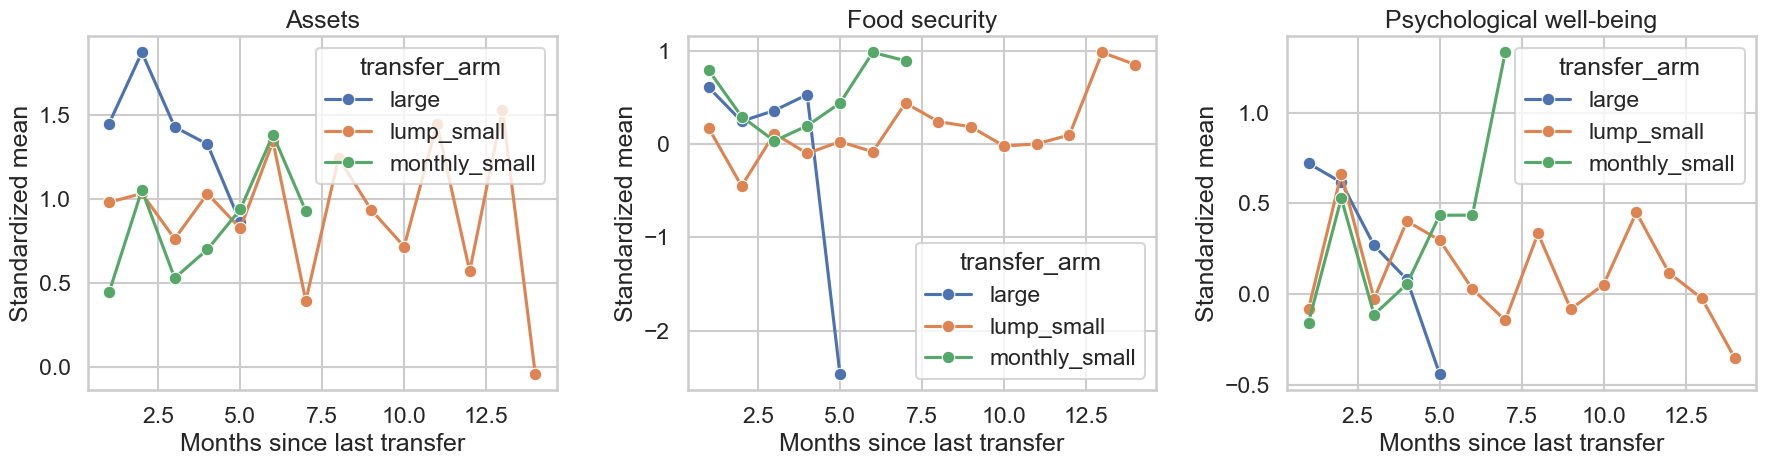

In [8]:
# Optional diagnostic: compare transfer arms separately.
treated_endline = long_df[(long_df["period"] == 1) & (long_df["treat"] == 1)].copy()
treated_endline = treated_endline[treated_endline["transfer_arm"].isin(["monthly_small", "lump_small", "large"])]

arm_profiles = (
    treated_endline.groupby(["transfer_arm", "event_month"])[z_cols]
    .mean()
    .reset_index()
)

focus_outcomes = ["asset_total_ppp_zscore", "fs_hhfoodindexnew_zscore", "psy_index_z_zscore"]
focus_labels = {
    "asset_total_ppp_zscore": "Assets",
    "fs_hhfoodindexnew_zscore": "Food security",
    "psy_index_z_zscore": "Psychological well-being",
}

fig, axes = plt.subplots(1, len(focus_outcomes), figsize=(18, 5), sharex=True)
for ax, outcome in zip(axes, focus_outcomes):
    sns.lineplot(
        data=arm_profiles,
        x="event_month",
        y=outcome,
        hue="transfer_arm",
        marker="o",
        ax=ax,
    )
    ax.set_title(focus_labels[outcome])
    ax.set_xlabel("Months since last transfer")
    ax.set_ylabel("Standardized mean")

plt.tight_layout()
plt.show()

## IV mechanism check: roof upgrades as the savings-and-credit channel

This section follows the paper's small-transfer timing design. Within the small-transfer group, households were randomly assigned to receive the transfer either as a **lump sum** or as **monthly transfers**. I use that random timing assignment as an instrument for whether the household had a **non-thatched roof at endline** (`asset_niceroof1`).

- **Endogenous variable:** `asset_niceroof1` (has non-thatched roof at endline)
- **Instrument:** `lump_sum` = 1 for `treatXlumpXsmall == 1`, 0 for `treatXmonthlyXsmall == 1`
- **Outcomes:** `fs_hhfoodindexnew1` and `psy_index_z1`
- **Paper link:** this uses the same lump-sum-versus-monthly variation emphasized in the original Haushofer and Shapiro timing-arm regressions, but repurposes it as an IV to test whether lumpy investment helps explain gains in food security and psychological well-being.

### IV equations

First stage:

$$
\text{Roof}_{i1} = \pi_0 + \pi_1 \text{LumpSum}_i + \gamma_v + u_i
$$

Reduced form for each outcome $Y \in \{\text{Food Security}, \text{Psychological Well-Being}\}$:

$$
Y_{i1} = \rho_0 + \rho_1 \text{LumpSum}_i + \rho_2 Y_{i0} + \gamma_v + \nu_i
$$

Second stage:

$$
Y_{i1} = \beta_0 + \beta_1 \widehat{\text{Roof}}_{i1} + \beta_2 Y_{i0} + \gamma_v + \varepsilon_i
$$

where $\gamma_v$ denotes village fixed effects.

### IV restriction checks

- **Relevance:** test $H_0: \pi_1 = 0$ in the first stage. With one instrument, the first-stage Wald statistic is the relevant F-style measure of instrument strength.
- **Exogeneity / exclusion:** in this exactly identified setup, the exclusion restriction $\mathrm{Cov}(\text{LumpSum}_i, \varepsilon_i)=0$ is **not directly testable** from the data. The notebook therefore reports **supporting evidence** using baseline balance checks on pre-treatment variables.

Interpretation: the 2SLS coefficient is a **local average treatment effect** of obtaining a non-thatched roof for households whose roof upgrading behavior was shifted by assignment to the lump-sum payment schedule.


,surveyid,village,lump_sum,monthly_small,asset_niceroof1
1,106769148.0,55,1,0,0.0
4,106979214.0,15,0,1,0.0
8,107470595.0,61,1,0,0.0
9,107646122.0,74,0,1,1.0
13,107756208.0,46,1,0,0.0


IV sample households: 343
lump_sum           0.536443
monthly_small      0.463557
asset_niceroof1    0.338192
Name: mean, dtype: float64


,coef,std_err,p_value,wald_F,n_obs
First stage: non-thatched roof on lump-sum assignment,0.1207,0.0608,0.0471,3.9421,343


,Outcome,Reduced-form coef on lump_sum,Reduced-form p-value,2SLS coef on non-thatched roof,2SLS cluster SE,2SLS p-value,N
0,Food security index,-0.2601,0.0878,-2.3828,27.3389,0.9305,343
1,Psychological well-being index,-0.0177,0.8449,-0.1712,8.9254,0.9847,333


,Check,coef_on_lump_sum,std_err,p_value,note
0,Baseline non-thatched roof,0.0000,0.0000,NaN,No baseline variation in the estimation sample
1,Baseline food security,-0.2723,0.1159,0.0188,Baseline imbalance: exogeneity support is weaker
2,Baseline psychological well-being,-0.1983,0.1248,0.1119,Baseline balance support for exogeneity


First-stage relevance: coef = 0.1207, cluster SE = 0.0608, p-value = 0.0471, Wald/F = 3.94.
Exogeneity note: because there is one instrument for one endogenous regressor, the exclusion restriction is not overidentification-testable here. Treat the baseline balance table as supporting evidence rather than a definitive test.


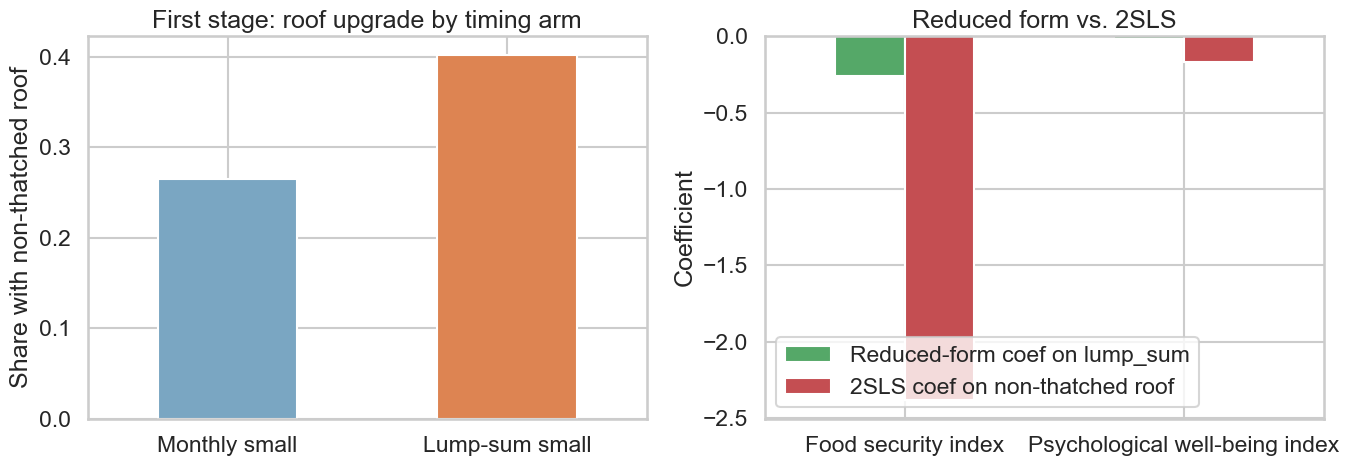

In [9]:
# Build the IV sample from the paper's small-transfer timing experiment.
iv_cols = [
    "surveyid",
    "village",
    "treatXsmall",
    "treatXlarge",
    "treatXmonthlyXsmall",
    "treatXlumpXsmall",
    "asset_niceroof0",
    "asset_niceroof1",
    "fs_hhfoodindexnew0",
    "fs_hhfoodindexnew1",
]

iv_df = (
    df_hh[iv_cols]
    .drop_duplicates(subset="surveyid")
    .merge(psych_household, on="surveyid", how="left")
)

iv_df = iv_df[(iv_df["treatXsmall"] == 1) & (iv_df["treatXlarge"] != 1)].copy()
iv_df["lump_sum"] = (iv_df["treatXlumpXsmall"] == 1).astype(int)
iv_df["monthly_small"] = (iv_df["treatXmonthlyXsmall"] == 1).astype(int)

display(iv_df[["surveyid", "village", "lump_sum", "monthly_small", "asset_niceroof1"]].head())
print(f"IV sample households: {len(iv_df):,}")
print(iv_df[["lump_sum", "monthly_small", "asset_niceroof1"]].mean().rename("mean"))

first_stage = smf.ols(
    "asset_niceroof1 ~ lump_sum + C(village)",
    data=iv_df,
).fit(cov_type="cluster", cov_kwds={"groups": iv_df["village"]})

first_stage_summary = pd.DataFrame({
    "coef": [first_stage.params["lump_sum"]],
    "std_err": [first_stage.bse["lump_sum"]],
    "p_value": [first_stage.pvalues["lump_sum"]],
    "wald_F": [float(first_stage.tvalues["lump_sum"] ** 2)],
    "n_obs": [int(first_stage.nobs)],
}, index=["First stage: non-thatched roof on lump-sum assignment"])

iv_results = []
outcome_labels = {
    "fs_hhfoodindexnew": "Food security index",
    "psy_index_z": "Psychological well-being index",
}

for outcome in ["fs_hhfoodindexnew", "psy_index_z"]:
    data = iv_df[[
        "surveyid",
        "village",
        "lump_sum",
        "asset_niceroof1",
        f"{outcome}0",
        f"{outcome}1",
    ]].dropna().copy()

    reduced_form = smf.ols(
        f"{outcome}1 ~ lump_sum + {outcome}0 + C(village)",
        data=data,
    ).fit(cov_type="cluster", cov_kwds={"groups": data["village"]})

    village_fe = pd.get_dummies(data["village"], prefix="village", drop_first=True, dtype=float)

    exog = pd.concat(
        [
            pd.DataFrame({
                "const": 1.0,
                "asset_niceroof1": data["asset_niceroof1"],
                f"{outcome}0": data[f"{outcome}0"],
            }),
            village_fe,
        ],
        axis=1,
    )

    instruments = pd.concat(
        [
            pd.DataFrame({
                "const": 1.0,
                "lump_sum": data["lump_sum"],
                f"{outcome}0": data[f"{outcome}0"],
            }),
            village_fe,
        ],
        axis=1,
    )

    iv_model = IV2SLS(data[f"{outcome}1"], exog, instruments).fit()
    iv_cov = cov_cluster(iv_model, data["village"])
    iv_se = pd.Series(np.sqrt(np.diag(iv_cov)), index=iv_model.params.index)
    iv_t = iv_model.params["asset_niceroof1"] / iv_se["asset_niceroof1"]
    iv_p = 2 * (1 - stats.norm.cdf(np.abs(iv_t)))

    iv_results.append({
        "Outcome": outcome_labels[outcome],
        "Reduced-form coef on lump_sum": reduced_form.params["lump_sum"],
        "Reduced-form p-value": reduced_form.pvalues["lump_sum"],
        "2SLS coef on non-thatched roof": iv_model.params["asset_niceroof1"],
        "2SLS cluster SE": iv_se["asset_niceroof1"],
        "2SLS p-value": iv_p,
        "N": int(iv_model.nobs),
    })

exogeneity_checks = []
for baseline_var, label in [
    ("asset_niceroof0", "Baseline non-thatched roof"),
    ("fs_hhfoodindexnew0", "Baseline food security"),
    ("psy_index_z0", "Baseline psychological well-being"),
]:
    data = iv_df[["village", "lump_sum", baseline_var]].dropna().copy()

    if data[baseline_var].nunique() <= 1:
        exogeneity_checks.append({
            "Check": label,
            "coef_on_lump_sum": 0.0,
            "std_err": 0.0,
            "p_value": np.nan,
            "note": "No baseline variation in the estimation sample",
        })
        continue

    balance_res = smf.ols(
        f"{baseline_var} ~ lump_sum + C(village)",
        data=data,
    ).fit(cov_type="cluster", cov_kwds={"groups": data["village"]})

    exogeneity_checks.append({
        "Check": label,
        "coef_on_lump_sum": balance_res.params["lump_sum"],
        "std_err": balance_res.bse["lump_sum"],
        "p_value": balance_res.pvalues["lump_sum"],
        "note": "Baseline balance support for exogeneity" if balance_res.pvalues["lump_sum"] >= 0.05 else "Baseline imbalance: exogeneity support is weaker",
    })

display(first_stage_summary.round(4))
display(pd.DataFrame(iv_results).round(4))
display(pd.DataFrame(exogeneity_checks).round(4))

print(
    f"First-stage relevance: coef = {first_stage.params['lump_sum']:.4f}, "
    f"cluster SE = {first_stage.bse['lump_sum']:.4f}, "
    f"p-value = {first_stage.pvalues['lump_sum']:.4f}, "
    f"Wald/F = {float(first_stage.tvalues['lump_sum'] ** 2):.2f}."
)
print(
    "Exogeneity note: because there is one instrument for one endogenous regressor, the exclusion restriction is not overidentification-testable here. "
    "Treat the baseline balance table as supporting evidence rather than a definitive test."
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
roof_rates = (
    iv_df.groupby("lump_sum")["asset_niceroof1"]
    .mean()
    .rename(index={0: "Monthly small", 1: "Lump-sum small"})
)
roof_rates.plot(kind="bar", ax=axes[0], color=["#7aa6c2", "#dd8452"])
axes[0].set_title("First stage: roof upgrade by timing arm")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share with non-thatched roof")
axes[0].tick_params(axis="x", rotation=0)

plot_df = pd.DataFrame(iv_results).set_index("Outcome")[[
    "Reduced-form coef on lump_sum",
    "2SLS coef on non-thatched roof",
]]
plot_df.plot(kind="bar", ax=axes[1], color=["#55a868", "#c44e52"])
axes[1].set_title("Reduced form vs. 2SLS")
axes[1].set_xlabel("")
axes[1].set_ylabel("Coefficient")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## XGBoost prediction exercise: what predicts improvement?

The clean research use of XGBoost in this project is **prediction and variable importance**, not latent-factor estimation. I use it to compare which observed pre-treatment and treatment-timing variables best predict:

1. **Material improvement**: `delta_asset = asset_total_ppp1 - asset_total_ppp0`
2. **Psychological improvement**: `delta_psy = psy_index_z1 - psy_index_z0`

This creates a direct comparison between the predictors of economic improvement and the predictors of psychological improvement.

### Target variables

- `delta_asset`: change in total assets between baseline and endline
- `delta_psy`: change in the household-level psychological well-being index between baseline and endline

### Feature design

The feature set is deliberately restricted to variables that are baseline, treatment-assignment, timing, or location variables:

- Baseline outcomes: assets, nondurable consumption, enterprise revenue, food security, psychological well-being
- Treatment and timing: treatment status, spillover status, transfer arm, assigned transfer amount, months since last transfer, and `transfer_amount × months_since_last_transfer`
- Baseline household characteristics: age, marriage, children, household size, education
- Baseline economic-status proxies: land, livestock, savings, business activity, own-farm participation
- Location: village dummies

### What is intentionally excluded

To keep the model interpretable, I do **not** include endline asset or endline psych measures as predictors. The model is therefore trying to explain improvement using pre-treatment conditions and treatment/timing variables rather than post-treatment bad controls.

### Evaluation

For each model, I report out-of-sample:

- RMSE
- MAE
- $R^2$

and I also report feature importance so we can compare what matters most for material versus psychological gains.


,model,target,n_obs,n_features_after_encoding,rmse,mae,r2
0,Model 1: Predict change in assets,delta_asset,940,84,459.3371,339.9467,0.3208
1,Model 2: Predict change in psychological well-...,delta_psy,903,84,0.8488,0.6556,0.5107


,feature,importance,model
0,spillover,0.0954,Model 1: Predict change in assets
1,treat,0.0888,Model 1: Predict change in assets
2,transfer_arm_large,0.0665,Model 1: Predict change in assets
3,assigned_transfer_ppp,0.0575,Model 1: Predict change in assets
4,asset_total_ppp0,0.0252,Model 1: Predict change in assets
5,village_292,0.0249,Model 1: Predict change in assets
6,transfer_arm_monthly_small,0.0210,Model 1: Predict change in assets
7,village_73,0.0188,Model 1: Predict change in assets
8,village_128,0.0183,Model 1: Predict change in assets
9,village_237,0.0175,Model 1: Predict change in assets


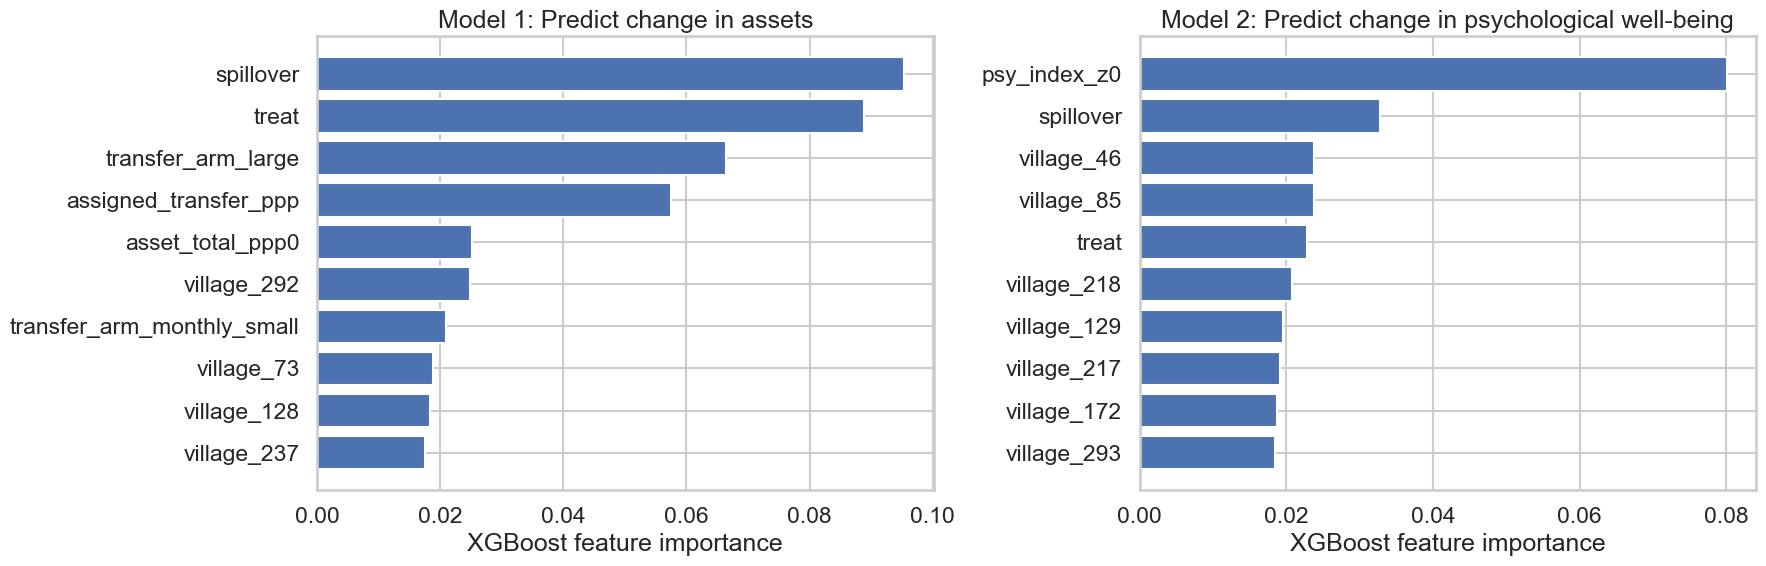

In [10]:
# Build a household-level prediction dataset for XGBoost.
xgb_base_cols = [
    "surveyid",
    "village",
    "treat",
    "spillover",
    "treatXlarge",
    "treatXsmall",
    "treatXmonthly",
    "treatXlump",
    "treatXmonthlyXsmall",
    "treatXlumpXsmall",
    "Dlastend",
    "asset_total_ppp0",
    "asset_total_ppp1",
    "cons_nondurable_ppp0",
    "ent_total_rev_ppp0",
    "fs_hhfoodindexnew0",
    "asset_land_owned_total0",
    "asset_livestock_ppp0",
    "asset_savings_ppp0",
    "ent_business0",
    "ent_ownfarm0",
    "b_age",
    "b_married",
    "b_children",
    "b_hhsize",
    "b_edu",
]

xgb_df = (
    df_hh[xgb_base_cols]
    .drop_duplicates(subset="surveyid")
    .merge(psych_household, on="surveyid", how="left")
)

xgb_df["assigned_transfer_ppp"] = np.select(
    [xgb_df["treat"] != 1, xgb_df["treatXlarge"] == 1, xgb_df["treat"] == 1],
    [0.0, TRANSFER_LARGE_PPP, TRANSFER_SMALL_PPP],
    default=np.nan,
)

xgb_df["transfer_arm"] = np.select(
    [
        xgb_df["treat"] != 1,
        xgb_df["treatXlarge"] == 1,
        xgb_df["treatXmonthly"] == 1,
        xgb_df["treatXlump"] == 1,
    ],
    ["control_or_spillover", "large", "monthly_small", "lump_small"],
    default="treated_other",
)

xgb_df["months_since_last_transfer"] = xgb_df["Dlastend"].fillna(0.0)
xgb_df["transfer_amount_x_months"] = (
    xgb_df["assigned_transfer_ppp"] * xgb_df["months_since_last_transfer"]
)

xgb_df["delta_asset"] = xgb_df["asset_total_ppp1"] - xgb_df["asset_total_ppp0"]
xgb_df["delta_psy"] = xgb_df["psy_index_z1"] - xgb_df["psy_index_z0"]

predictor_cols = [
    "asset_total_ppp0",
    "cons_nondurable_ppp0",
    "ent_total_rev_ppp0",
    "fs_hhfoodindexnew0",
    "psy_index_z0",
    "treat",
    "spillover",
    "assigned_transfer_ppp",
    "months_since_last_transfer",
    "transfer_amount_x_months",
    "b_age",
    "b_married",
    "b_children",
    "b_hhsize",
    "b_edu",
    "asset_land_owned_total0",
    "asset_livestock_ppp0",
    "asset_savings_ppp0",
    "ent_business0",
    "ent_ownfarm0",
    "transfer_arm",
    "village",
]

def run_xgboost_prediction(data, target, predictors, random_state=42):
    model_df = data[predictors + [target]].dropna(subset=[target]).copy()
    X = pd.get_dummies(model_df[predictors], columns=["transfer_arm", "village"], drop_first=False)
    y = model_df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=random_state,
    )

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        n_jobs=1,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    metrics = {
        "target": target,
        "n_obs": len(model_df),
        "n_features_after_encoding": X.shape[1],
        "rmse": mean_squared_error(y_test, y_pred) ** 0.5,
        "mae": mean_absolute_error(y_test, y_pred),
        "r2": r2_score(y_test, y_pred),
    }

    feature_importance = (
        pd.Series(model.feature_importances_, index=X.columns, name="importance")
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"index": "feature"})
    )

    return metrics, feature_importance, model

xgb_targets = {
    "delta_asset": "Model 1: Predict change in assets",
    "delta_psy": "Model 2: Predict change in psychological well-being",
}

xgb_metric_rows = []
xgb_top_features = []

for target, label in xgb_targets.items():
    metrics, feature_importance, fitted_model = run_xgboost_prediction(
        xgb_df,
        target=target,
        predictors=predictor_cols,
    )

    metrics["model"] = label
    xgb_metric_rows.append(metrics)

    top_features = feature_importance.head(15).copy()
    top_features["model"] = label
    xgb_top_features.append(top_features)

xgb_metrics = pd.DataFrame(xgb_metric_rows)[[
    "model",
    "target",
    "n_obs",
    "n_features_after_encoding",
    "rmse",
    "mae",
    "r2",
]]

xgb_top_features = pd.concat(xgb_top_features, ignore_index=True)

display(xgb_metrics.round(4))
display(xgb_top_features.round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, (label, subset) in zip(axes, xgb_top_features.groupby("model")):
    plot_df = subset.head(10).iloc[::-1]
    ax.barh(plot_df["feature"], plot_df["importance"], color="#4c72b0")
    ax.set_title(label)
    ax.set_xlabel("XGBoost feature importance")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


## How to read the results

- If the latent factor rises immediately after transfer and the economic outcomes have the strongest positive correlation with it first, that supports the idea that material conditions improve early.
- If `psy_index_z` loads strongly and moves with the common factor at the same event months as assets and consumption, the response looks contemporaneous.
- If the psych series adjusts more slowly than assets or food security, that is evidence of temporal ordering consistent with the causal chain in your screenshot.

## Next extensions

1. Replace the assigned-transfer proxy with an exact cumulative transfer path if you later obtain the payment ledger.
2. Estimate separate DFMs for `monthly_small`, `lump_small`, and `large` arms.
3. Add village fixed-effect residualization before aggregation if you want a stricter within-village interpretation.
4. Add bootstrap confidence intervals for the smoothed factor path.